# Bước 3: Mô hình Phân khúc khách hàng

Notebook này thực hiện phân khúc khách hàng sử dụng các kỹ thuật clustering.

## Mục tiêu

1. Tải features đã xử lý từ kỹ thuật tạo features
2. Áp dụng Phân tích thành phần chính (PCA) để trực quan hóa dữ liệu
3. Xác định số cluster tối ưu
4. Áp dụng K-Means clustering
5. Phân tích và diễn giải các phân khúc khách hàng
6. Lưu kết quả phân cụm

## Phân khúc khách hàng là gì?

Phân khúc khách hàng là quá trình chia khách hàng thành các nhóm dựa trên các đặc điểm chung. Điều này giúp doanh nghiệp:
- Hiểu được các hành vi khách hàng khác nhau
- Nhắm mục tiêu các nỗ lực marketing hiệu quả hơn
- Cải thiện dịch vụ khách hàng
- Tăng khả năng giữ chân khách hàng

## Import thư viện

In [181]:
%load_ext autoreload
%autoreload 2

# Import thư viện
import sys
sys.path.append('../src')

from clustering_library import ClusterAnalyzer
import matplotlib.pyplot as plt
import pandas as pd

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Tải dữ liệu đã xử lý

In [182]:
# Tải features đã chuẩn hóa (chuẩn bị cho clustering)
scaled_path = '../data/processed/customer_features_scaled.csv'
original_path = '../data/processed/customer_features.csv'

# Khởi tạo cluster analyzer và tải dữ liệu
analyzer = ClusterAnalyzer(scaled_path, original_path)
df_scaled, df_original = analyzer.load_data()

df_scaled.head()

Số khách hàng: 3920
Số features: 16


,Sum_Quantity,Mean_UnitPrice,Mean_TotalPrice,Sum_TotalPrice,Count_Invoice,Count_Stock,Mean_InvoiceCountPerStock,Mean_StockCountPerInvoice,Mean_UnitPriceMeanPerInvoice,Mean_QuantitySumPerInvoice,Mean_TotalPriceMeanPerInvoice,Mean_TotalPriceSumPerInvoice,Mean_UnitPriceMeanPerStock,Mean_QuantitySumPerStock,Mean_TotalPriceMeanPerStock,Mean_TotalPriceSumPerStock
CustomerID,,,,,,,,,,,,,,,,
12346,3.851787,-2.120200,3.800724,3.208210,-1.158331,-2.283759,-1.017361,-2.306882,-2.100615,8.841886,3.718256,7.383300,-2.142004,3.387146,3.763067,3.342710
12747,0.882453,0.880121,1.006951,1.405645,1.534230,0.154796,1.951879,-0.614242,0.751290,-0.306068,0.973938,0.485462,1.080004,1.042357,0.667834,1.528082
12748,3.079104,-0.106164,-1.068831,2.739703,2.354232,4.051134,1.976092,0.343426,1.876575,-0.238963,-0.080134,-0.710380,-0.048723,0.348918,-0.892094,-0.000453
12749,0.987040,1.125774,0.282458,1.387919,0.891601,1.406192,0.541901,1.096745,1.058261,0.755990,0.259807,1.528552,1.057839,-0.159472,0.290815,0.330463
12820,0.466541,-0.816774,-0.020015,0.295441,0.658243,0.394558,-0.410914,-0.123310,-0.825019,0.189277,-0.104723,-0.181862,-0.935086,0.239145,0.003566,-0.128590


In [183]:
# Kiểm tra thống kê cơ bản
print("Thống kê mô tả dữ liệu đã chuẩn hóa:")
df_scaled.describe().round(2)

Thống kê mô tả dữ liệu đã chuẩn hóa:


,Sum_Quantity,Mean_UnitPrice,Mean_TotalPrice,Sum_TotalPrice,Count_Invoice,Count_Stock,Mean_InvoiceCountPerStock,Mean_StockCountPerInvoice,Mean_UnitPriceMeanPerInvoice,Mean_QuantitySumPerInvoice,Mean_TotalPriceMeanPerInvoice,Mean_TotalPriceSumPerInvoice,Mean_UnitPriceMeanPerStock,Mean_QuantitySumPerStock,Mean_TotalPriceMeanPerStock,Mean_TotalPriceSumPerStock
count,3920.00,3920.00,3920.00,3920.00,3920.00,3920.00,3920.00,3920.00,3920.00,3920.00,3920.00,3920.00,3920.00,3920.00,3920.00,3920.00
mean,-0.00,0.00,0.00,0.00,0.00,0.00,0.00,-0.00,0.00,0.00,0.00,-0.00,0.00,-0.00,0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-3.86,-5.07,-2.99,-4.98,-1.16,-2.28,-1.02,-2.31,-5.07,-4.20,-3.04,-6.00,-5.14,-2.99,-3.00,-3.17
25%,-0.66,-0.55,-0.48,-0.65,-1.16,-0.70,-1.02,-0.65,-0.56,-0.58,-0.42,-0.60,-0.55,-0.57,-0.50,-0.45
50%,-0.03,0.04,0.08,0.00,-0.20,-0.00,-0.23,0.02,0.05,0.03,0.02,0.07,0.06,0.07,0.10,0.02
75%,0.67,0.59,0.48,0.69,0.89,0.70,0.81,0.64,0.57,0.62,0.48,0.58,0.58,0.56,0.47,0.51
max,3.92,4.55,3.80,3.84,2.35,4.05,2.06,4.20,3.97,8.84,3.73,7.49,4.53,3.39,3.76,3.34


## Phân tích thành phần chính (PCA)

PCA giúp chúng ta:
- Giảm số chiều trong dữ liệu
- Trực quan hóa dữ liệu nhiều chiều trong 2D hoặc 3D
- Hiểu features nào quan trọng nhất
- Loại bỏ nhiễu và thông tin dư thừa

In [184]:
# Áp dụng PCA
df_pca = analyzer.apply_pca()
df_pca.head()

Tự động chọn 3 components (giữ lại 86.1% variance ≥ 85%)
PCA shape: (3920, 3)


,PC1,PC2,PC3
CustomerID,,,
12346,11.910657,-2.897237,5.229854
12747,3.291884,-0.262965,-2.106278
12748,1.105211,-4.686764,-3.254707
12749,1.479671,-1.811752,-2.676471
12820,0.197741,-0.993728,1.155410


### Tỷ lệ phương sai được giải thích

Biểu thị lượng thông tin (phương sai) mà mỗi thành phần chính nắm bắt được.

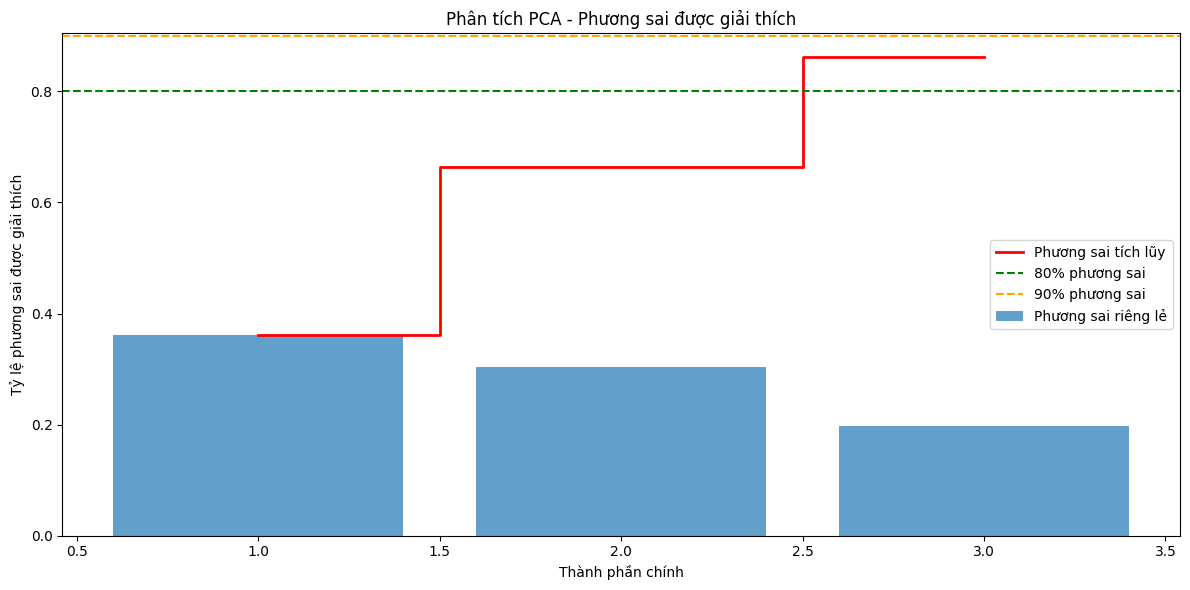


Phương sai tích lũy:
PC1-PC1: 36.09%
PC1-PC2: 66.44%
PC1-PC3: 86.12%


In [185]:
# Biểu đồ tỷ lệ phương sai được giải thích
analyzer.plot_pca_variance()

## Xác định số Cluster tối ưu

Tìm số cluster phù hợp (k) là điều quan trọng cho việc phân khúc có ý nghĩa. Chúng ta sẽ sử dụng hai phương pháp bổ sung:

1. **Phương pháp Elbow**: Tìm "khuỷu tay" trong đường cong inertia
2. **Silhouette Score**: Tìm k có điểm silhouette trung bình cao nhất

Sử dụng cả hai phương pháp cùng nhau giúp chúng ta tin tưởng hơn vào việc chọn k.

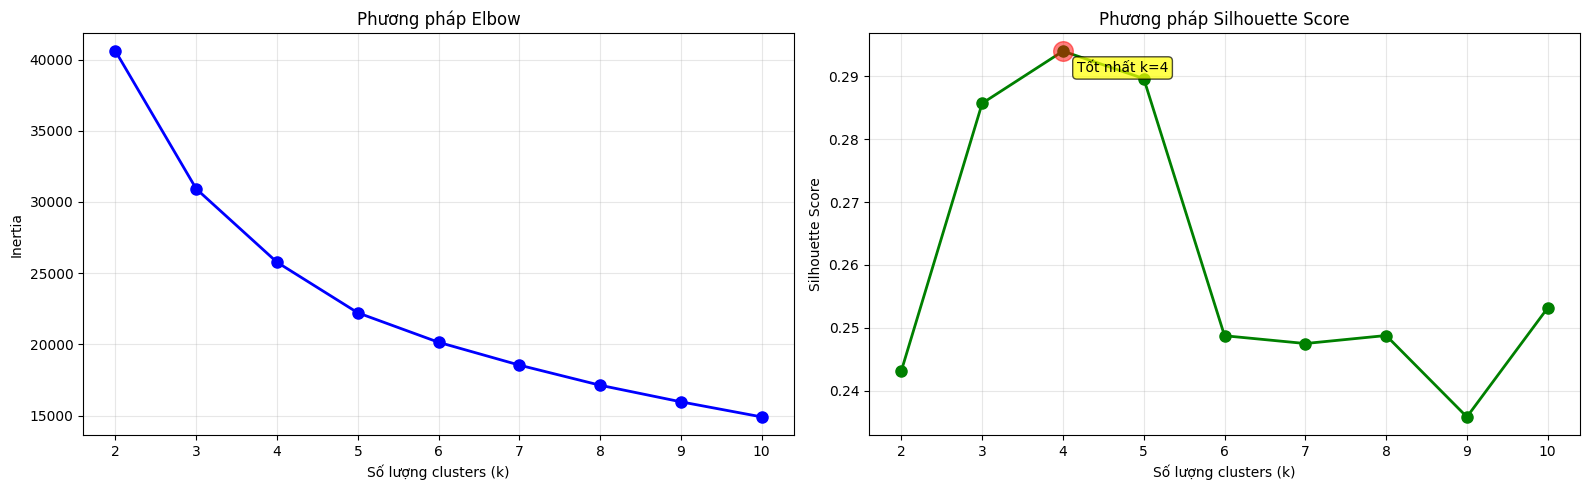

Silhouette Score đề xuất: k=4 (điểm số = 0.294)


In [186]:
# Tìm số cluster tối ưu
optimal_results = analyzer.find_optimal_clusters()

# Vẽ biểu đồ so sánh các phương pháp
analyzer.plot_optimal_clusters()


## K-Means Clustering

Chúng ta sẽ áp dụng K-Means clustering với các giá trị k khác nhau (3 và 4) và so sánh kết quả.

Kích thước clusters (k=3):
0    1523
1    1533
2     864
Name: count, dtype: int64
Kích thước clusters (k=4):
0     682
1    1059
2    1352
3     827
Name: count, dtype: int64


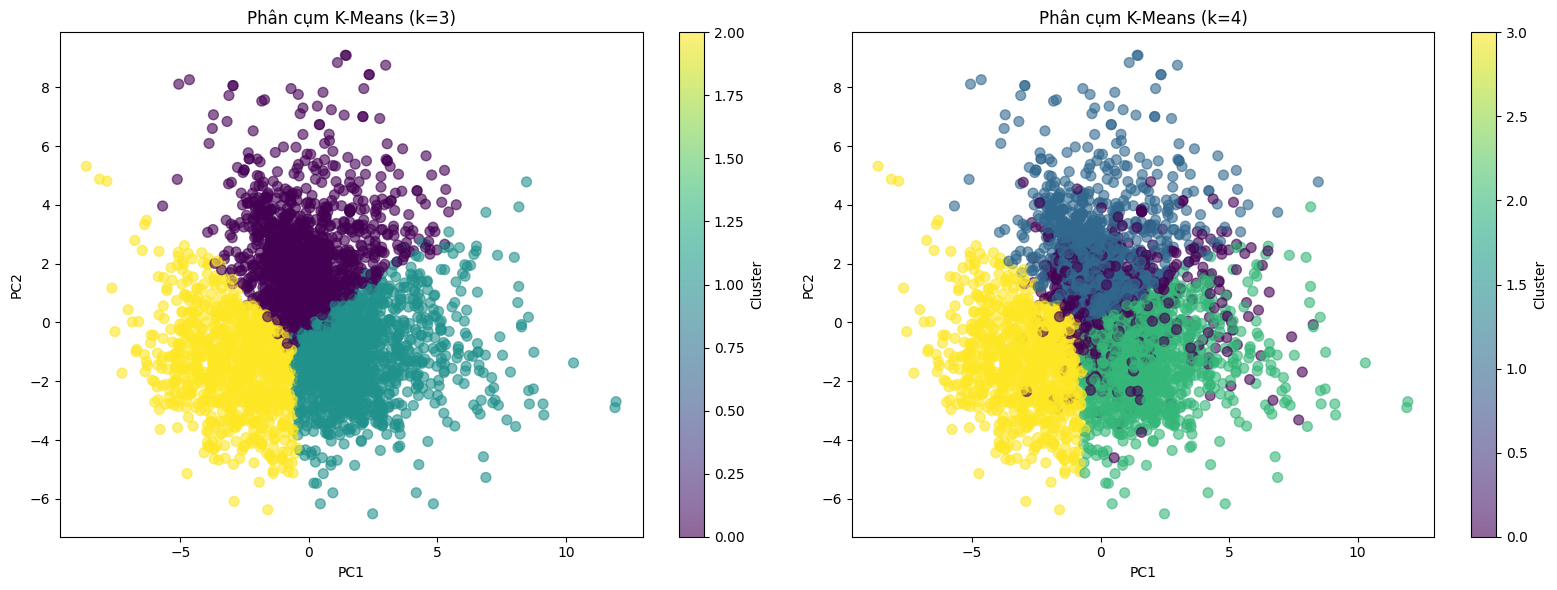

In [187]:
# Áp dụng K-Means với k=3 và k=4
cluster_results = analyzer.apply_kmeans([3, 4])

# Trực quan hóa clusters trong không gian PCA
analyzer.plot_clusters_pca([3, 4])


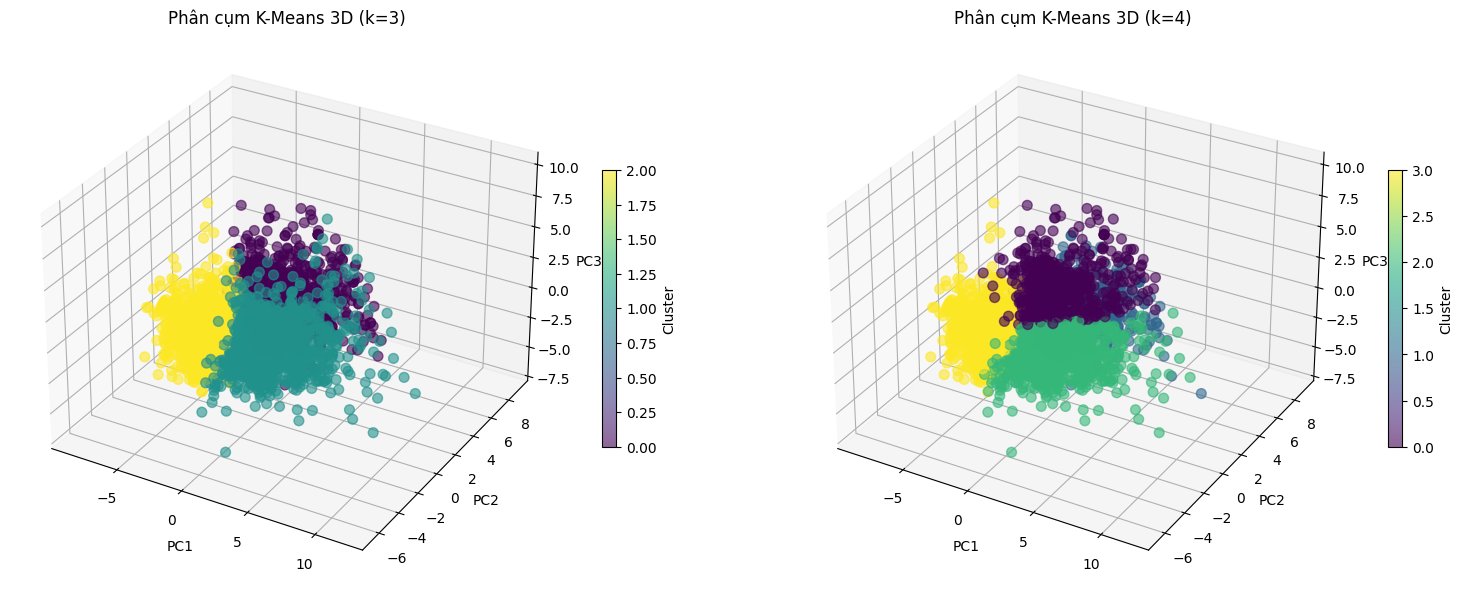

In [188]:
# Trực quan hóa clusters trong không gian PCA 3D
analyzer.plot_clusters_pca_3d([3, 4])

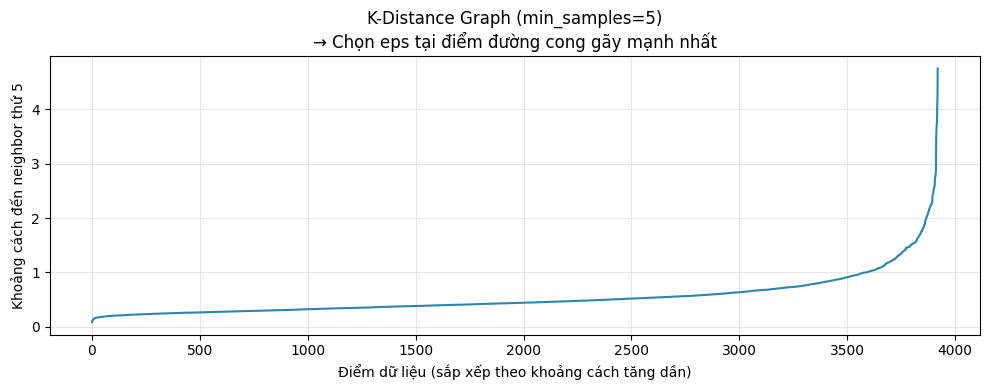

In [189]:
# Cell mới 1 — Tìm eps tối ưu cho DBSCAN
analyzer.plot_dbscan_tuning(min_samples=5)

In [190]:
# Cell mới 2 — Chạy DBSCAN với eps chọn từ k-distance graph ở trên
dbscan_labels = analyzer.apply_dbscan(eps=0.8, min_samples=5)
# Điều chỉnh eps dựa vào điểm gãy trên biểu đồ — thử vài giá trị nếu cần

DBSCAN (eps=0.8, min_samples=5)
  Số cluster tìm được : 5
  Noise points        : 381 (9.7%)
  Silhouette↑        : 0.160
  Davies-Bouldin↓    : 0.595
  Calinski-Harabasz↑ : 21.7


In [191]:
# Cell mới 3 — Bảng so sánh K-Means, GMM, DBSCAN
df_compare = analyzer.compare_clustering(k_values=[3, 4], include_dbscan=True)

Silhouette↑  Davies-Bouldin↓  \
Thuật toán Tham số                                                       
K-Means    k=3                                  0.286            1.225   
           k=4                                  0.294            1.139   
GMM        k=3, cov=full                        0.108            2.414   
           k=3, cov=tied                        0.199            1.224   
           k=3, cov=diag                        0.124            3.231   
           k=4, cov=full                        0.197            1.828   
           k=4, cov=tied                        0.204            1.187   
           k=4, cov=diag                        0.237            1.904   
DBSCAN     eps=0.8, ms=5, k=5, noise=381        0.160            0.595   

                                          Calinski-Harabasz↑  
Thuật toán Tham số                                            
K-Means    k=3                                      1462.857  
           k=4                                      1431.104  
GMM        k=3, cov=full                             514.376  
           k=3, cov=tied                             513.950  
           k=3, cov=diag                             502.551  
           k=4, cov=full                             897.280  
           k=4, cov=tied                             543.023  
           k=4, cov=diag                             857.013  
DBSCAN     eps=0.8, ms=5, k=5, noise=381              21.712

### Kết luận: Chọn thuật toán tối ưu

Bảng so sánh dưới đây phản ánh lần chạy mới nhất của notebook sau khi tính metrics trên PCA thuần và bỏ các cột nhãn cụm phát sinh trong quá trình phân tích.

| Thuật toán | Cấu hình | Silhouette↑ | Davies-Bouldin↓ | Calinski-Harabasz↑ |
|---|---|---|---|---|
| **K-Means** | **k=4** | **0.294** | **1.139** | **1431.1** |
| K-Means | k=3 | 0.286 | 1.225 | 1462.9 |
| GMM | k=4, diag | 0.237 | 1.904 | 857.0 |
| GMM | k=4, full | 0.197 | 1.828 | 897.3 |
| DBSCAN | eps=0.8, ms=5 (k=5) | 0.160 | 0.595 | 21.7 |

**K-Means k=4** vẫn là lựa chọn chính để diễn giải nghiệp vụ vì cho Silhouette cao nhất trong các cấu hình đã thử và giữ được mức phân tách tốt hơn K=3 trong lần rerun mới nhất.

Các điểm đáng chú ý từ bảng mới nhất:

- K=4 cho Silhouette cao nhất, nhưng mức chênh so với K=3 là nhỏ, nên đây là cải thiện nhẹ chứ không phải nhảy vọt.
- Calinski-Harabasz của K=3 đang cao hơn K=4, nên nếu ưu tiên độ chặt cụm thuần túy thì K=3 vẫn là một ứng viên cần cân nhắc.
- GMM và DBSCAN hiện cho kết quả thấp hơn rõ rệt, nên phù hợp hơn như benchmark tham chiếu thay vì phương án chính.

**Lưu ý cho phần thảo luận của luận văn:** Silhouette Score sau khi tối ưu hiện ở mức xấp xỉ 0.29-0.30, thấp hơn con số cũ trong notebook trước khi mình sửa pipeline, nhưng đây là mức đáng tin cậy hơn vì metrics không còn bị méo bởi cột nhãn cụm và các phép đo trên dữ liệu đã bị mutate.

## Phân tích và diễn giải Cluster

Hãy phân tích đặc điểm của từng cluster để hiểu các phân khúc khách hàng khác nhau.

In [192]:
# Thống kê trung bình cho từng cluster
print("=== PHÂN TÍCH CLUSTER K=3 ===")
cluster_means_3 = cluster_results[3]['means']
cluster_sizes_3 = cluster_results[3]['sizes']

print("Kích thước clusters:")
for cluster, size in cluster_sizes_3.items():
    print(f"- Cluster {cluster}: {size:,} khách hàng ({size/cluster_sizes_3.sum()*100:.1f}%)")

display(cluster_means_3.round(2).style.background_gradient(cmap='viridis', axis=0))

=== PHÂN TÍCH CLUSTER K=3 ===
Kích thước clusters:
- Cluster 0: 1,523 khách hàng (38.9%)
- Cluster 1: 1,533 khách hàng (39.1%)
- Cluster 2: 864 khách hàng (22.0%)


,Sum_Quantity,Mean_UnitPrice,Mean_TotalPrice,Sum_TotalPrice,Count_Invoice,Count_Stock,Mean_InvoiceCountPerStock,Mean_StockCountPerInvoice,Mean_UnitPriceMeanPerInvoice,Mean_QuantitySumPerInvoice,Mean_TotalPriceMeanPerInvoice,Mean_TotalPriceSumPerInvoice,Mean_UnitPriceMeanPerStock,Mean_QuantitySumPerStock,Mean_TotalPriceMeanPerStock,Mean_TotalPriceSumPerStock
Cluster_3,,,,,,,,,,,,,,,,
0,177.820000,6.370000,34.200000,359.290000,1.700000,15.890000,1.080000,10.990000,6.890000,120.540000,36.020000,233.880000,6.370000,17.150000,33.640000,39.910000
1,2332.470000,3.590000,145.980000,3976.650000,7.320000,85.650000,1.490000,21.430000,4.250000,411.700000,170.980000,633.820000,3.810000,131.830000,143.950000,197.700000
2,474.830000,2.610000,6.280000,769.660000,3.280000,95.540000,1.220000,42.180000,2.760000,160.510000,7.100000,247.690000,2.630000,4.820000,6.250000,7.570000


In [193]:
# Thống kê trung bình cho từng cluster k=4
print("=== PHÂN TÍCH CLUSTER K=4 ===")
cluster_means_4 = cluster_results[4]['means']
cluster_sizes_4 = cluster_results[4]['sizes']

print("Kích thước clusters:")
for cluster, size in cluster_sizes_4.items():
    print(f"- Cluster {cluster}: {size:,} khách hàng ({size/cluster_sizes_4.sum()*100:.1f}%)")

display(cluster_means_4.round(2).style.background_gradient(cmap='viridis', axis=0))

=== PHÂN TÍCH CLUSTER K=4 ===
Kích thước clusters:
- Cluster 0: 682 khách hàng (17.4%)
- Cluster 1: 1,059 khách hàng (27.0%)
- Cluster 2: 1,352 khách hàng (34.5%)
- Cluster 3: 827 khách hàng (21.1%)


,Sum_Quantity,Mean_UnitPrice,Mean_TotalPrice,Sum_TotalPrice,Count_Invoice,Count_Stock,Mean_InvoiceCountPerStock,Mean_StockCountPerInvoice,Mean_UnitPriceMeanPerInvoice,Mean_QuantitySumPerInvoice,Mean_TotalPriceMeanPerInvoice,Mean_TotalPriceSumPerInvoice,Mean_UnitPriceMeanPerStock,Mean_QuantitySumPerStock,Mean_TotalPriceMeanPerStock,Mean_TotalPriceSumPerStock
Cluster_4,,,,,,,,,,,,,,,,
0,504.790000,1.690000,48.970000,484.160000,1.770000,18.420000,1.120000,12.810000,1.700000,296.250000,51.490000,303.210000,1.690000,80.440000,48.530000,60.770000
1,161.860000,8.900000,48.720000,441.870000,1.850000,16.460000,1.100000,10.660000,9.630000,96.200000,51.070000,251.890000,8.890000,13.070000,48.060000,81.290000
2,2497.000000,3.490000,141.430000,4371.860000,8.010000,96.920000,1.510000,23.020000,4.260000,387.880000,168.760000,642.170000,3.720000,118.330000,139.240000,175.100000
3,441.490000,2.640000,6.160000,724.910000,3.200000,93.130000,1.210000,42.170000,2.740000,151.210000,6.930000,241.950000,2.660000,4.470000,6.130000,7.400000


### Biểu đồ Radar cho hồ sơ Cluster

Biểu đồ Radar giúp chúng ta visualize đặc điểm của từng cluster một cách trực quan.

#### Cách đọc Radar Chart:

1. **Mỗi trục = 1 đặc điểm khách hàng** (đã được chuẩn hóa về scale 0-1)
2. **Càng xa tâm = giá trị càng cao** cho đặc điểm đó
3. **Hình dạng của đa giác** cho thấy "hồ sơ" của cluster
4. **So sánh các cluster** bằng cách nhìn vào hình dạng và kích thước

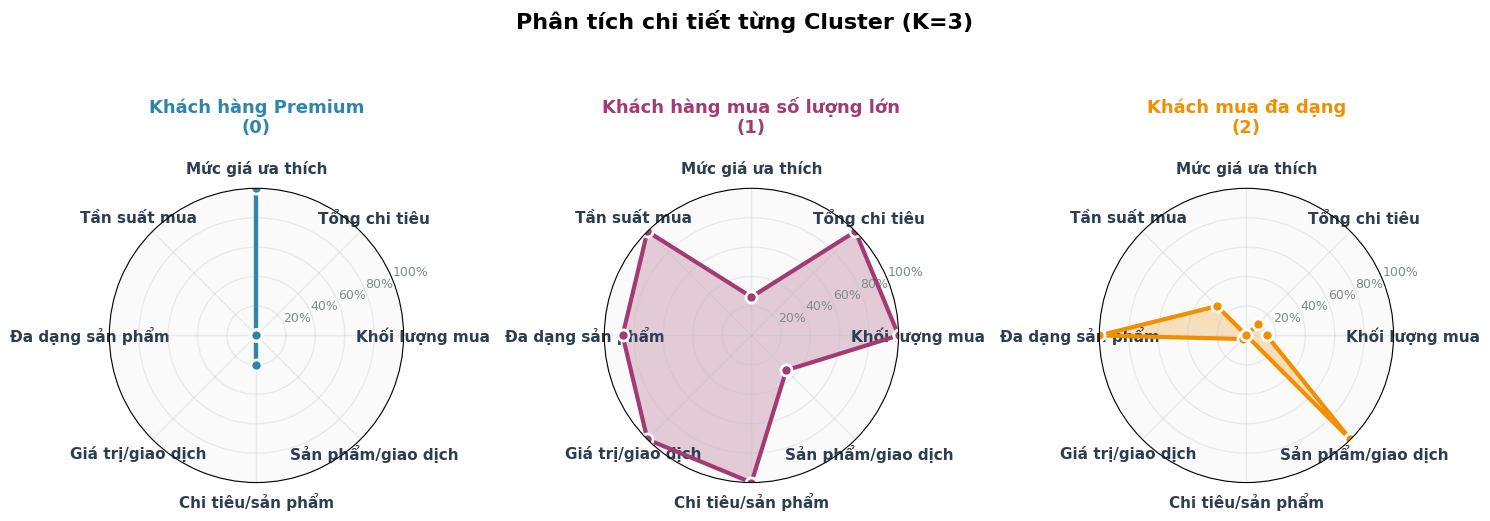

In [194]:
# Tạo individual radar plots cho k=3
analyzer.create_individual_radar_plots(3, ['Khách hàng Premium', 'Khách hàng mua số lượng lớn', 'Khách mua đa dạng'])

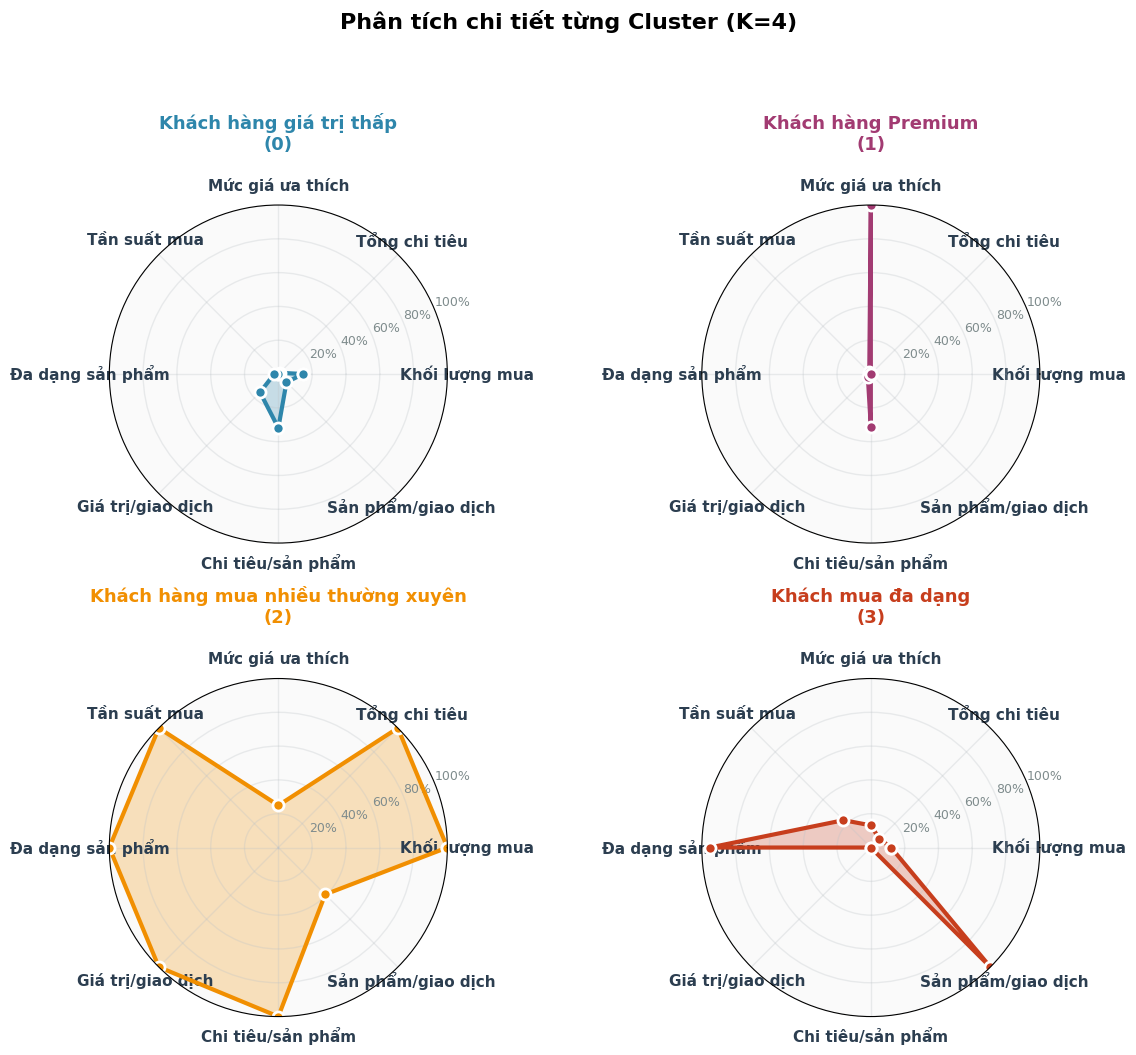

In [195]:
# Tạo individual radar plots cho k=4
analyzer.create_individual_radar_plots(4, ['Khách hàng giá trị thấp', 'Khách hàng Premium', 'Khách hàng mua nhiều thường xuyên', 'Khách mua đa dạng'])

### Phân tích Radar Chart

**So sánh k=3 vs k=4 (dựa trên bảng cluster means thực tế của lần chạy mới nhất):**

**Với K=3 clusters:**
- **Cluster 0 (38.9% - 1,523 khách)**: **Khách hàng Premium**
  - Giá trung bình cao nhất: 6.37 (so với 3.59 và 2.61)
  - Số lượng mua thấp: 177.8 sản phẩm
  - Ít giao dịch: 1.70 hóa đơn, tổng chi tiêu 359.3

- **Cluster 1 (39.1% - 1,533 khách)**: **Khách hàng Mua Số Lượng Lớn**
  - Số lượng mua cao nhất: 2,332 (gấp ~13 lần cluster 0)
  - Giá thấp nhất: 3.59 (chiết khấu số lượng)
  - Nhiều giao dịch nhất: 7.32 hóa đơn, tổng chi tiêu cao nhất: 3,977

- **Cluster 2 (22.0% - 864 khách)**: **Khách hàng Khám Phá Đa Dạng**
  - Mua nhiều loại sản phẩm nhất: 95.5 loại
  - Giá thấp: 2.61, tổng chi tiêu 769.7
  - Giao dịch vừa phải: 3.28 hóa đơn

**Với K=4 clusters — quan trọng: thứ tự và ý nghĩa của từng cluster ĐÃ THAY ĐỔI so với các phiên bản trước đây do một lỗi tính khoảng cách đã được khắc phục (xem phần Kết luận chọn thuật toán ở trên). Phân tích dưới đây dựa trên bảng cluster means thực tế của lần chạy mới nhất:**

- **Cluster 0 (17.4% - 682 khách)**: **Khách hàng Giá Trị Thấp** *(nhóm mới xuất hiện khi tách từ K=3)*
  - Giá thấp nhất trong 4 cluster: 1.69
  - Tổng chi tiêu thấp nhất: 484.2
  - Ít giao dịch nhất cùng với Cluster 1: 1.77 hóa đơn
  - Đặc điểm: mua ít, giá rẻ, đóng góp doanh thu thấp nhất

- **Cluster 1 (27.0% - 1,059 khách)**: **Khách hàng Premium**
  - Giá cao nhất trong 4 cluster: 8.90 (cao hơn cả Premium ở K=3)
  - Số lượng mua thấp nhất: 161.9
  - Ít giao dịch: 1.85 hóa đơn — mua ít nhưng giá trị mỗi sản phẩm rất cao

- **Cluster 2 (34.5% - 1,352 khách)**: **Khách hàng Mua Nhiều Thường Xuyên** *(cluster lớn nhất)*
  - Số lượng mua cao nhất: 2,497
  - Nhiều giao dịch nhất: 8.01 hóa đơn
  - Tổng chi tiêu cao nhất: 4,372 — nhóm đóng góp doanh thu lớn nhất

- **Cluster 3 (21.1% - 827 khách)**: **Khách hàng Đa Dạng**
  - Mua nhiều loại sản phẩm nhất: 93.1 loại — gần tương đương Cluster 2 K=3
  - Giá thấp: 2.64
  - Giao dịch vừa phải: 3.20 hóa đơn

#### Insights từ Radar Chart:

**1. K=4 tách "Premium" của K=3 thành 2 nhóm có ý nghĩa khác nhau rõ rệt:**
- Ở K=3, Cluster Premium (giá trung bình 6.37) thực chất là **con số trung bình gộp giữa 2 nhóm khác nhau**: khách hàng thực sự cao cấp (giá ~8.90) và khách hàng giá trị thấp, ít gắn kết (giá ~1.69)
- K=4 tách đúng thành **Cluster 1 (Premium thật, 27.0%)** và **Cluster 0 (Giá trị thấp, 17.4%)**
- Đây là bằng chứng thuyết phục nhất cho việc chọn K=4: không chỉ Silhouette Score cao hơn một chút, mà còn phát hiện ra một phân khúc khách hàng có ý nghĩa kinh doanh riêng biệt mà K=3 đã che khuất

**2. Pattern Recognition từ Radar Chart:**
- **Cluster 1 (Premium)**: "Spike" cao ở UnitPrice, thấp ở Quantity → khách hàng chi nhiều tiền cho từng sản phẩm
- **Cluster 2 (Mua Nhiều Thường Xuyên)**: "Spike" cao ở Quantity + Invoice count + tổng chi tiêu → nhóm đóng góp doanh thu lớn nhất, có thể là khách B2B/wholesaler
- **Cluster 3 (Đa dạng)**: Cân bằng ở Stock diversity, giá thấp → khách hàng khám phá nhiều sản phẩm khác nhau
- **Cluster 0 (Giá trị thấp)**: Thấp ở hầu hết các chỉ số → nhóm ít gắn kết, cơ hội để phát triển thành khách hàng trung thành hơn

**3. Giá trị kinh doanh của K=4 so với K=3:**

**K=3 Problems:**
- Cluster "Premium" (38.9%) thực chất gộp 2 nhóm hành vi khác nhau (giá cao thật vs giá trị thấp), làm loãng insight khi làm marketing target
- Khó thiết kế chiến lược riêng cho từng nhóm nhỏ bên trong

**K=4 Solutions:**
- **Segmentation chính xác hơn**: tách rõ khách Premium thật khỏi khách giá trị thấp
- **Actionable insights**: mỗi cluster có chiến lược riêng, không còn lẫn lộn
- **Phát hiện nhóm cần chú ý**: Cluster 0 (giá trị thấp) là nhóm có thể cần chiến lược kích hoạt lại (re-engagement)

**4. Strategic Recommendations dựa trên K=4:**
- **Cluster 0 (Giá trị thấp, 17.4%)**: Chiến dịch kích hoạt lại, ưu đãi giới thiệu sản phẩm giá tốt để tăng tần suất mua
- **Cluster 1 (Premium, 27.0%)**: VIP program, tập trung sản phẩm cao cấp, dịch vụ khách hàng ưu tiên
- **Cluster 2 (Mua Nhiều Thường Xuyên, 34.5%)**: Chiết khấu theo số lượng, dịch vụ B2B, chương trình subscription
- **Cluster 3 (Đa dạng, 21.1%)**: Hệ thống gợi ý sản phẩm (recommendation engine), cross-selling

**5. Kết luận: K=4 phù hợp hơn cho ứng dụng kinh doanh**
- **Độ chi tiết**: phân khúc rõ ràng hơn mà không chia quá nhỏ
- **Tính khả thi**: mỗi cluster có kế hoạch hành động riêng dựa trên đặc điểm thực tế
- **Phát hiện giá trị**: tách được nhóm Premium thật và nhóm giá trị thấp — insight mà K=3 không thể hiện được

## Lưu kết quả phân cụm

In [196]:
# Lưu kết quả phân cụm cho cả k=3 và k=4
analyzer.save_clusters()

Đã lưu kết quả phân cụm k=3: ../data/processed/customer_clusters_k3.csv
Đã lưu kết quả phân cụm k=4: ../data/processed/customer_clusters_k4.csv
Đã lưu kết quả DBSCAN: ../data/processed/customer_clusters_dbscan_eps0.8_ms5.csv


## Giải thích Cluster với SHAP Values

**SHAP (SHapley Additive exPlanations)** là một phương pháp giải thích mô hình giúp xác định feature nào đóng góp nhiều nhất vào một dự đoán cụ thể.

### Tại sao cần SHAP cho Clustering?

Radar Chart giúp mô tả đặc điểm trung bình của mỗi cluster, nhưng không trả lời trực tiếp câu hỏi:

> **"Tại sao khách hàng A thuộc Cluster 2 thay vì Cluster 1?"**

SHAP giải quyết vấn đề này bằng cách:

1. **Quantify Feature Importance**: Đo lường mức độ ảnh hưởng của từng feature.
2. **Individual Explanations**: Giải thích tại sao một khách hàng cụ thể thuộc cluster đó.
3. **Compare with Alternatives**: So sánh khách hàng với các cluster khác.

### Phương pháp: Mô hình surrogate

Vì K-Means là **unsupervised learning**, chúng ta dùng một mô hình thay thế để học lại nhãn cụm mà K-Means tạo ra, từ đó có thể giải thích bằng SHAP:

1. **Train RandomForestClassifier** để dự đoán cluster assignments từ K-Means.
2. **Apply SHAP TreeExplainer** để giải thích predictions của Random Forest.
3. **Interpret**: SHAP values cho biết feature nào khiến model (và gián tiếp K-Means) gán khách hàng vào một cluster cụ thể.

### So sánh SHAP vs Radar Chart

| Aspect | Radar Chart | SHAP Values |
|--------|-------------|-------------|
| **Mục đích** | Visualize cluster profiles | Explain individual predictions |
| **Level** | Cluster-level (trung bình) | Customer-level + Cluster-level |
| **Câu hỏi trả lời** | "Cluster này có đặc điểm gì?" | "Tại sao khách hàng X ở cluster Y?" |
| **Feature selection** | 6-8 features chọn thủ công | Toàn bộ features quan trọng, xếp hạng theo độ ảnh hưởng |

**Kết luận**: Radar Chart và SHAP bổ sung cho nhau, không thay thế cho nhau.

### Bước 1: Train Surrogate Models

Chúng ta sẽ train RandomForestClassifier cho cả k=3 và k=4 để dự đoán cluster assignments.

In [197]:
# Train surrogate model cho k=3
surrogate_results_3 = analyzer.train_surrogate_model(3)

=== HUẤN LUYỆN MÔ HÌNH THAY THẾ (k=3) ===
Độ chính xác train: 1.0000 (100.00%)
Độ chính xác test  : 0.9770 (97.70%)

Confusion Matrix:
[[299   0   6]
 [  3 299   4]
 [  5   0 168]]

Mô hình có thể dự đoán CHÍNH XÁC các phân cụm.


In [198]:
# Train surrogate model cho k=4
surrogate_results_4 = analyzer.train_surrogate_model(4)

=== HUẤN LUYỆN MÔ HÌNH THAY THẾ (k=4) ===
Độ chính xác train: 1.0000 (100.00%)
Độ chính xác test  : 0.9528 (95.28%)

Confusion Matrix:
[[126   7   4   0]
 [  1 205   4   2]
 [  3   4 258   5]
 [  1   4   2 158]]

Mô hình có thể dự đoán CHÍNH XÁC các phân cụm.


### Bước 2: Tính toán SHAP Values

Sau khi train/test split để đánh giá mô hình surrogate, notebook refit lại model trên toàn bộ 3,920 khách hàng trước khi tính SHAP values. Cách này giúp phần giải thích bám sát model cuối cùng được dùng để diễn giải cluster.

In [199]:
# Tính SHAP values cho k=3
shap_results_3 = analyzer.calculate_shap_values(3)

Tính toán SHAP values cho 3,920 khách hàng...
Hoàn thành! SHAP values: 3 clusters, mỗi cluster shape: (3920, 16)


In [200]:
# Tính SHAP values cho k=4
shap_results_4 = analyzer.calculate_shap_values(4)

Tính toán SHAP values cho 3,920 khách hàng...
Hoàn thành! SHAP values: 4 clusters, mỗi cluster shape: (3920, 16)


### Bước 3: SHAP Feature Importance (Global View)

Biểu đồ SHAP Beeswarm cho thấy mức độ quan trọng của đủ **16 features** trong mô hình surrogate và cách giá trị của chúng ảnh hưởng đến việc phân loại từng khách hàng vào một cluster cụ thể.

**Cách đọc:**
- **Trục Y**: Các features được sắp xếp theo độ quan trọng trung bình (từ trên xuống dưới).
- **Trục X**: Giá trị SHAP (SHAP value).
  - Giá trị **dương**: feature đó đang đẩy dự đoán về phía cluster đang xem.
  - Giá trị **âm**: feature đó đang kéo dự đoán ra xa cluster đang xem.
- **Màu sắc**: Giá trị thực tế của feature.
  - **Đỏ**: Giá trị cao.
  - **Xanh**: Giá trị thấp.
- **Mỗi điểm**: Đại diện cho một khách hàng.

Vì SHAP đang giải thích surrogate model, phần diễn giải bên dưới nên được hiểu là xu hướng quan trọng nổi bật của 16 features, không phải một quy tắc tuyệt đối cho từng khách hàng riêng lẻ.


── Cluster 0 ──


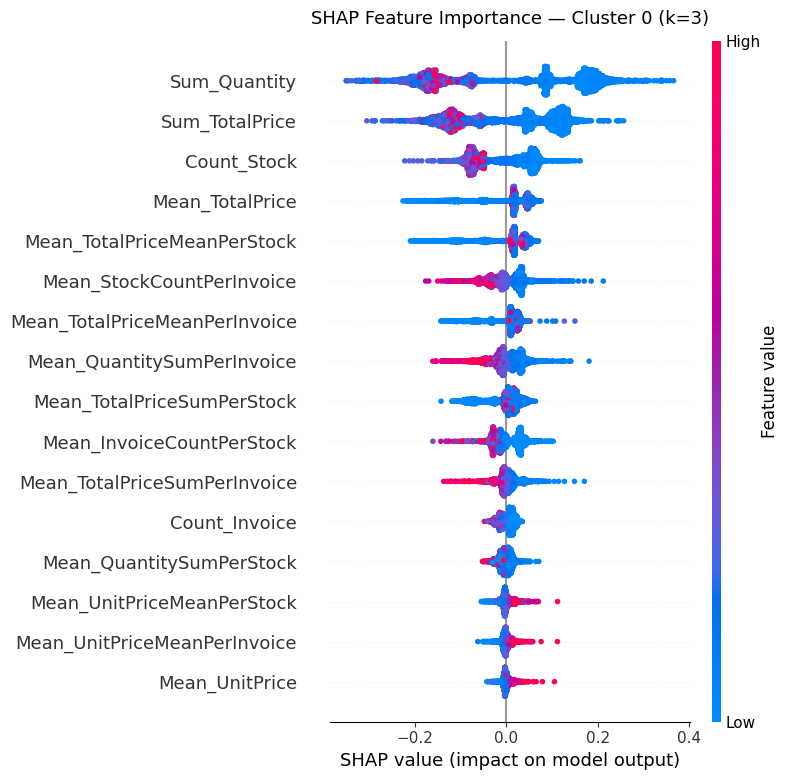


── Cluster 1 ──


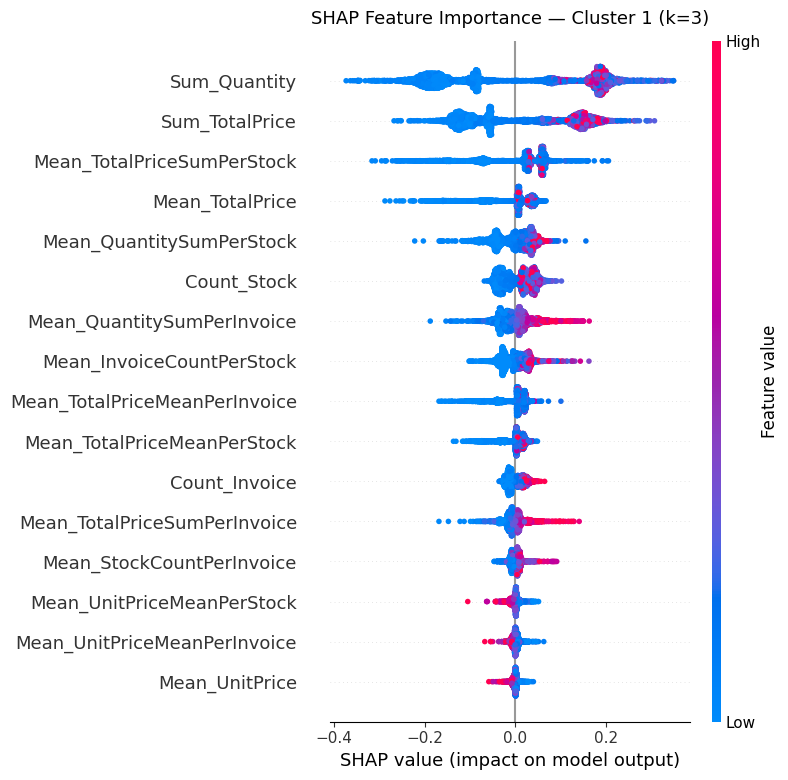


── Cluster 2 ──


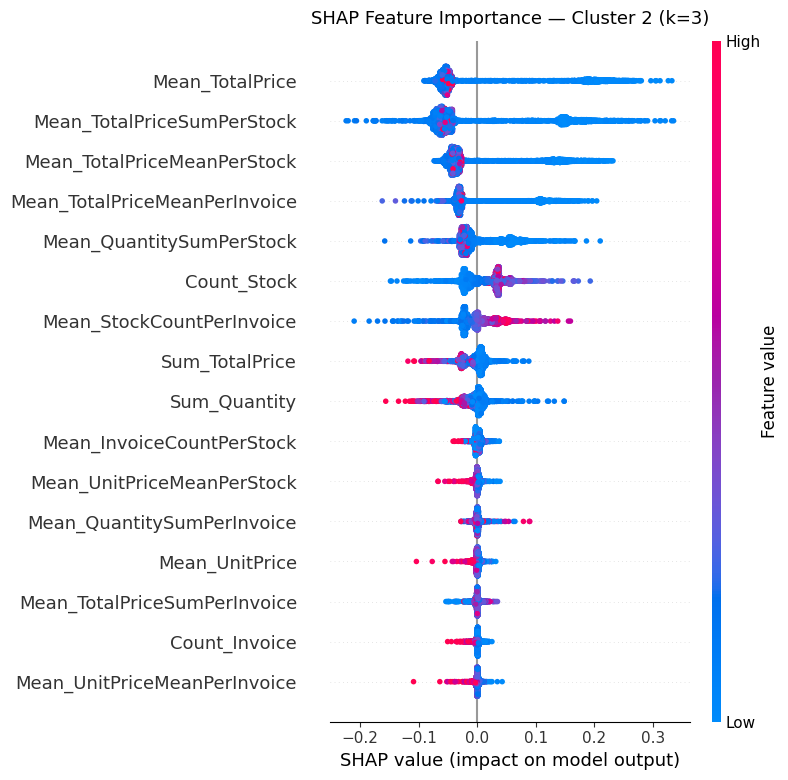

In [201]:
analyzer.plot_shap_summary(3)

### So sánh kết quả SHAP và Radar Chart (K=3)

Dựa trên biểu đồ Radar và biểu đồ SHAP Summary cho 3 cụm khách hàng, chúng ta có thể rút ra các so sánh chi tiết dưới đây. Lưu ý rằng Radar Chart chỉ dùng một tập nhỏ feature đại diện, còn SHAP đang xét toàn bộ **16 features** của surrogate model.

**Cluster 0 (Nhóm giá trị giao dịch cao nhưng quy mô mua nhỏ hơn)**
*   **Radar Chart:** Nổi bật ở Mean_UnitPrice và Mean_TotalPrice, trong khi khối lượng và tần suất không cao bằng Cluster 1.
*   **SHAP:** Các biến Sum_Quantity, Sum_TotalPrice và Count_Stock vẫn là những tín hiệu quan trọng, cho thấy mô hình không chỉ dựa vào giá trung bình mà còn dùng đồng thời quy mô mua và mức độ đa dạng sản phẩm để tách cụm này.

**Cluster 1 (Khách hàng mua số lượng lớn)**
*   **Radar Chart:** Bao phủ diện tích lớn nhất ở Sum_TotalPrice, Sum_Quantity và Count_Invoice.
*   **SHAP:** Sum_Quantity và Sum_TotalPrice là hai biến có ảnh hưởng mạnh nhất, phù hợp với việc cluster này đại diện cho nhóm mua nhiều và chi tiêu nhiều hơn mặt bằng chung.

**Cluster 2 (Khách mua đa dạng)**
*   **Radar Chart:** Mở rộng về phía Count_Stock và Mean_StockCountPerInvoice.
*   **SHAP:** Các feature liên quan đến mức độ đa dạng sản phẩm và hành vi theo giao dịch tiếp tục xuất hiện nổi bật, cho thấy cụm này được tách ra không chỉ bởi số lượng mua mà còn bởi cách khách hàng phân tán danh mục mua sắm.

Việc kết hợp Radar Chart và SHAP Beeswarm Chart mang lại cái nhìn đa chiều:
*   **Radar Chart** giúp hình dung nhanh "hình dáng" đặc trưng của từng nhóm dựa trên các chỉ số KPI đại diện.
*   **SHAP** đi sâu vào giải thích "tại sao" và cho biết 16 features nào đang đóng góp mạnh nhất cho từng cluster.
Sự kết hợp này giúp doanh nghiệp không chỉ nhận diện được khách hàng mà còn hiểu sâu động lực hành vi của họ để có chiến lược tác động phù hợp.


── Cluster 0 ──


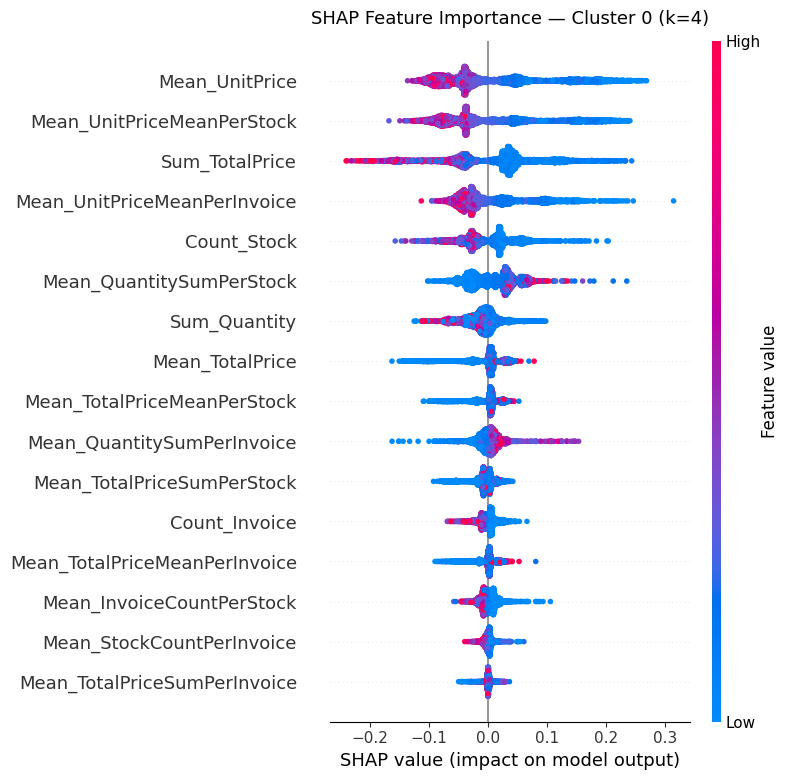


── Cluster 1 ──


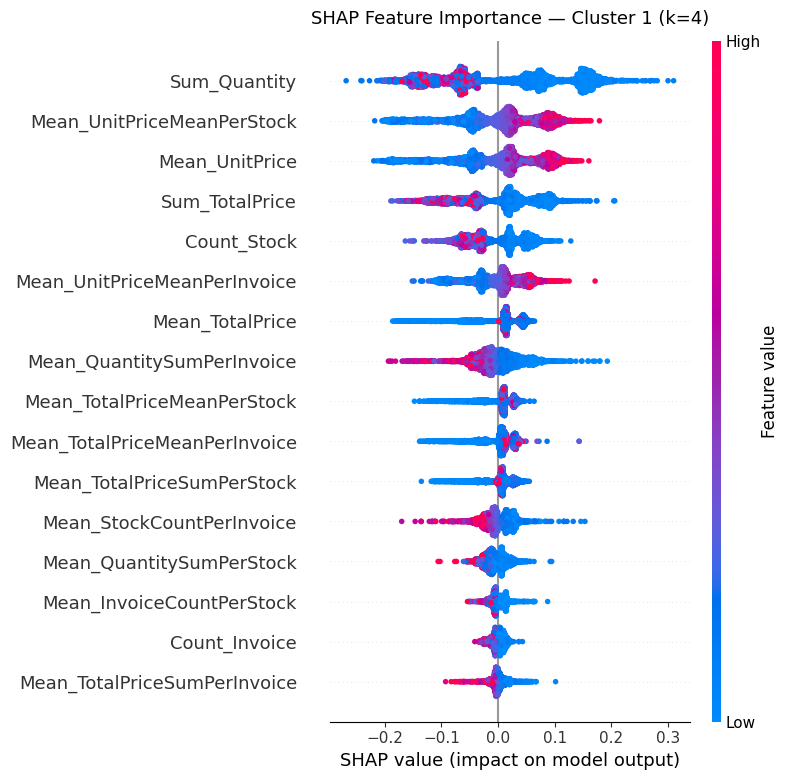


── Cluster 2 ──


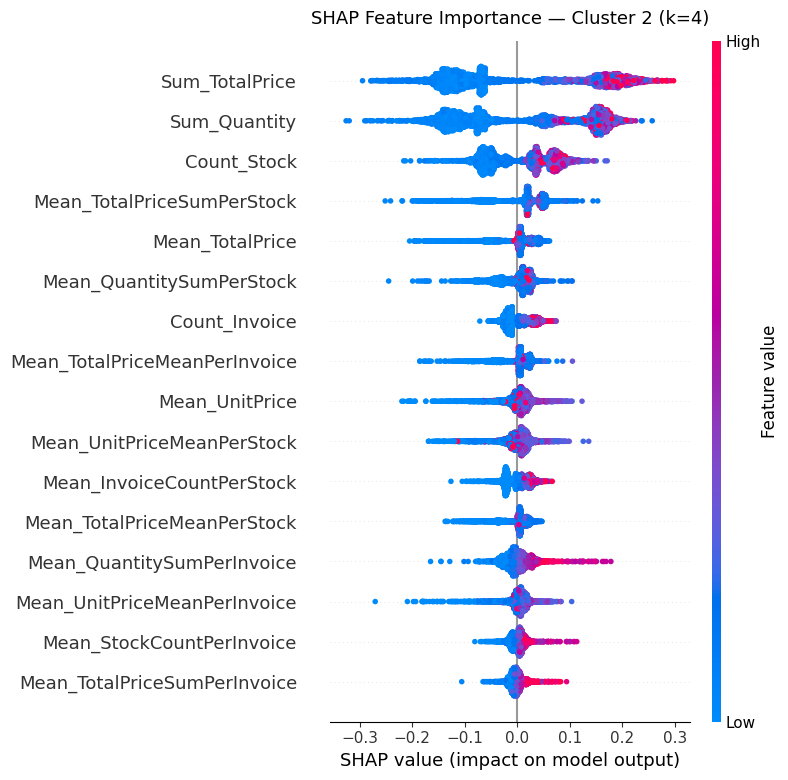


── Cluster 3 ──


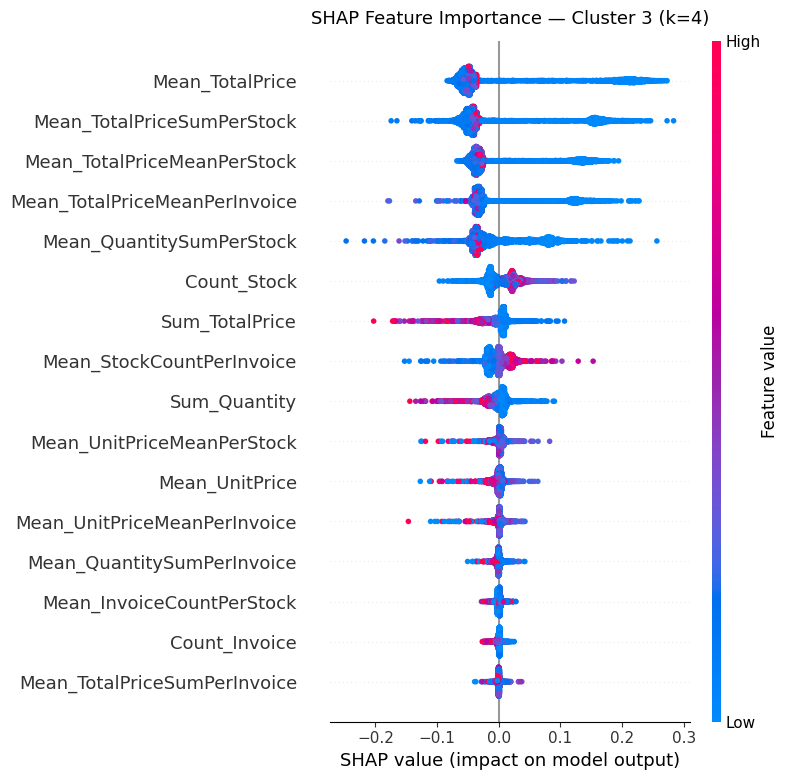

In [202]:
analyzer.plot_shap_summary(4)

### Phân tích chi tiết SHAP cho K=4

Khi mở rộng phân cụm lên K=4, biểu đồ SHAP Beeswarm cung cấp cái nhìn sâu sắc hơn về cách các nhóm khách hàng được tách biệt, đặc biệt là việc tách cụm mua số lượng lớn thành các nhóm khác nhau theo mức chi tiêu, giá trung bình và độ đa dạng sản phẩm.

**Cluster 0 (Nhóm chi tiêu thấp hơn, quy mô mua trung bình)**
*   **SHAP:** Nhóm này không nổi bật bằng Cluster 1 về giá trung bình, cũng không nổi bật bằng Cluster 2 về quy mô mua. Vì vậy, các feature liên quan đến mức giá và tổng giá trị giao dịch thường đóng vai trò phân biệt hơn là chỉ riêng khối lượng mua.

**Cluster 1 (Khách hàng Premium / giá trung bình cao)**
*   **Radar Chart:** Nổi bật nhất ở Mean_UnitPrice.
*   **SHAP:** Mean_UnitPrice là tín hiệu phân tách mạnh, phù hợp với việc đây là nhóm khách hàng mua với mức giá trung bình cao hơn các cụm còn lại.

**Cluster 2 (Khách hàng Mua Nhiều Thường Xuyên)**
*   **Radar Chart:** Nổi bật ở Sum_Quantity, Sum_TotalPrice và Count_Invoice.
*   **SHAP:** Các biến Sum_Quantity và Sum_TotalPrice có tác động tích cực mạnh, xác nhận đây là nhóm khách hàng có quy mô mua và doanh số cao nhất.

**Cluster 3 (Khách hàng Đa Dạng)**
*   **Radar Chart:** Nổi bật ở Count_Stock và Mean_StockCountPerInvoice.
*   **SHAP:** Các feature liên quan đến danh mục mua sắm và số sản phẩm trên mỗi giao dịch đóng vai trò chủ đạo, cho thấy sự đa dạng là yếu tố quyết định để mô hình tách nhóm này ra.

**Kết luận**
Ở K=4, SHAP cho thấy ranh giới quyết định rõ hơn giữa các nhóm. Quan trọng hơn, phần diễn giải này đang được suy ra từ toàn bộ 16 features của surrogate model, nên nó phản ánh xu hướng phân tách của mô hình chứ không chỉ riêng một chỉ số trên radar chart.

### Key Insights từ SHAP Analysis

**Feature Importance**
SHAP values cho thấy ranking của các features theo mức độ quan trọng, giúp:
- **Thu thập dữ liệu tốt hơn**: Tập trung vào features có impact cao.
- **Feature engineering**: Biết features nào cần refine.
- **Kế hoạch kinh doanh tốt hơn**: Align KPIs với important features.

**Cho chúng ta thêm một góc nhìn khác**:
- Radar Chart = **What** (cluster có đặc điểm gì)
- SHAP = **Why** (tại sao khách hàng thuộc cluster đó)

**Actionable**: Kết hợp cả hai cách để hiểu rõ hơn nhóm khách hàng của chúng ta.

**Model Trustworthiness**
Mô hình surrogate được đánh giá trên **tập test** tách riêng nên các con số accuracy ở phần này phản ánh khả năng tổng quát hóa chứ không chỉ là mức độ ghi nhớ dữ liệu train. Điều này làm cho phần giải thích SHAP đáng tin cậy hơn khi đem diễn giải sang nghiệp vụ.

## Tóm tắt

Trong notebook này, chúng ta đã:

1. **Tải features đã xử lý** - đã chuẩn hóa và sẵn sàng cho clustering.
2. **Áp dụng PCA** để hiểu cấu trúc dữ liệu và giảm chiều.
   - 2-3 thành phần đầu giải thích phần lớn phương sai.
   - Trực quan hóa phân phối khách hàng trong không gian thấp chiều.
3. **Xác định số cluster tối ưu** bằng Silhouette Score.
   - Kiểm tra k=2 đến k=10.
   - So sánh K-Means, GMM và DBSCAN trên cùng một không gian PCA.
4. **Áp dụng K-Means clustering** với k=3 và k=4.
   - Tạo các phân khúc khách hàng.
   - Trực quan hóa clusters trong không gian PCA.
5. **Phân tích đặc điểm cluster**.
   - Xác định các phân khúc khách hàng riêng biệt.
   - Sử dụng biểu đồ radar để diễn giải.
6. **Giải thích clusters với SHAP values**.
   - Train RandomForest surrogate với train/test split.
   - Refine lại surrogate trên toàn bộ 3,920 khách hàng trước khi tính SHAP values.
   - Visualize feature importance.
   - Validate với Radar Chart.
7. **Lưu kết quả phân cụm** để sử dụng kinh doanh.

### Phát hiện chính:

- Khách hàng có thể được phân khúc có ý nghĩa thành 3-4 nhóm.
- Mỗi phân khúc có hành vi mua hàng riêng biệt.
- K=4 đang cho Silhouette tốt nhất trong lần rerun mới nhất, nhưng K=3 có Calinski-Harabasz cao hơn nên đây là bài toán đánh đổi giữa độ tách cụm và độ chặt cụm.
- SHAP analysis thể hiện features nào quan trọng nhất cho mỗi cluster.

### Đề xuất kinh doanh:

1. **Khách hàng giá trị cao**: Tập trung vào chương trình giữ chân và VIP.
2. **Người khám phá sản phẩm**: Khuyến khích mua hàng thông qua đề xuất và cross-sell.
3. **Người mua sắm Premium**: Làm nổi bật chất lượng và sản phẩm độc quyền.
4. **Người mua số lượng lớn**: Cung cấp dịch vụ đăng ký và chiết khấu số lượng lớn.